# 02. Data Preparation and Cleaning

**CRISP-DM Phase**: Data Preparation  
**Mục tiêu**: Chuẩn bị dữ liệu sạch, đáng tin cậy cho các bài toán phân tích và mô hình hóa tiếp theo.

### Các nội dung chính:
1. Chuẩn hóa kiểu dữ liệu cho toàn bộ các thuộc tính và tính `TotalAmount`.
2. Gắn cờ và phân tích chuyên sâu các hóa đơn hủy (`C`) và bút toán điều chỉnh nợ xấu (`A`).
3. Phân loại và xử lý các `StockCode` phi sản phẩm (cước phí, mẫu thử, điều chỉnh hệ thống).
4. Xử lý giá trị thiếu (`Description`, `CustomerID`) theo chiến lược nhất quán.
5. Loại bỏ dữ liệu không hợp lệ (`Quantity <= 0`, `UnitPrice <= 0`) và các dòng trùng lặp (`duplicate`).
6. Phân tích giá trị bất thường (outlier) bằng phương pháp IQR và gắn cờ cảnh báo.
7. Tạo 3 tập dữ liệu sạch (`cleaned_transactions`, `customer_transactions`, `product_transactions`) phục vụ từng bài toán chuyên biệt.
8. Trực quan hóa và so sánh dữ liệu trước và sau làm sạch.
9. Kiểm tra tính toàn vẹn, đảm bảo dữ liệu gốc không bị biến đổi.


In [1]:
# Thiết lập môi trường và import thư viện
import sys
import os
from pathlib import Path

# Đảm bảo đường dẫn gốc project được nhận diện
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    RAW_DATA_CSV, INTERIM_DIR,
    FIGURES_DATA_PREPARATION, TABLES_DATA_PREPARATION,
    NON_PRODUCT_STOCK_CODES
)
from src.data_loader import load_raw_data
from src.preprocessing import (
    standardize_dtypes,
    add_transaction_flags,
    classify_stock_codes,
    fill_missing_descriptions,
    report_missing_values,
    remove_invalid_transactions,
    handle_duplicates,
    detect_outliers,
    create_clean_datasets,
    save_cleaning_report
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

print("Import thành công các module từ src.config và src.preprocessing!")


Import thành công các module từ src.config và src.preprocessing!


## 1. Đọc Dữ Liệu Gốc (Raw Data)

Tải tập dữ liệu gốc từ `data/raw/Online Retail.csv` thông qua hàm chuẩn hóa `load_raw_data()`.  
Ghi nhận kích thước ban đầu để làm căn cứ đối chiếu trong toàn bộ pipeline làm sạch.


In [2]:
df_raw = load_raw_data()
raw_rows, raw_cols = df_raw.shape

print(f"Kích thước dữ liệu gốc: {raw_rows:,} dòng x {raw_cols} cột")
print(f"Số hóa đơn duy nhất   : {df_raw['InvoiceNo'].nunique():,}")
print(f"Số sản phẩm duy nhất  : {df_raw['StockCode'].nunique():,}")
print(f"Số khách hàng có ID   : {df_raw['CustomerID'].nunique():,}")

df_raw.head()


[OK] Da tai du lieu: 541,909 dong x 8 cot
Kích thước dữ liệu gốc: 541,909 dòng x 8 cột
Số hóa đơn duy nhất   : 25,900
Số sản phẩm duy nhất  : 4,070
Số khách hàng có ID   : 4,372


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom


## 2. Chuẩn Hóa Kiểu Dữ Liệu & Tạo TotalAmount

- `InvoiceNo` và `StockCode` được ép về kiểu chuỗi ký tự (`string`), loại bỏ khoảng trắng thừa.
- `InvoiceDate` được chuyển về kiểu `datetime64[ns]`.
- `Quantity` ép về `int64`, `UnitPrice` ép về `float64`.
- Tạo thuộc tính dẫn xuất cấp giao dịch: `TotalAmount = Quantity * UnitPrice`.


In [3]:
# Tạo bản sao để xử lý, bảo toàn df_raw
df = df_raw.copy()
df = standardize_dtypes(df)

print("Thông tin kiểu dữ liệu sau chuẩn hóa:")
print(df.dtypes)
print("\nThống kê mô tả biến TotalAmount:")
print(df['TotalAmount'].describe())


Thông tin kiểu dữ liệu sau chuẩn hóa:
InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
TotalAmount           float64
dtype: object

Thống kê mô tả biến TotalAmount:
count    541,909.00
mean          17.99
std          378.81
min     -168,469.60
25%            3.40
50%            9.75
75%           17.40
max      168,469.60
Name: TotalAmount, dtype: float64


## 3. Gắn Cờ Giao Dịch (Transaction Flags)

Nhằm phục vụ phân tích chuyên sâu và theo dõi chi tiết quá trình làm sạch, ta tạo 5 cờ boolean:
- `IsCancelled`: Hóa đơn bắt đầu bằng ký tự `'C'` (đơn hủy).
- `IsAdjust`: Hóa đơn bắt đầu bằng ký tự `'A'` (bút toán nợ xấu).
- `IsDuplicate`: Dòng trùng lặp hoàn toàn trên 8 thuộc tính ban đầu.
- `IsQuantityInvalid`: Số lượng mua `<= 0`.
- `IsPriceInvalid`: Đơn giá `<= 0`.


In [4]:
df = add_transaction_flags(df)

flags_summary = pd.DataFrame({
    'Flag': ['IsCancelled', 'IsAdjust', 'IsDuplicate', 'IsQuantityInvalid', 'IsPriceInvalid'],
    'TrueCount': [
        df['IsCancelled'].sum(),
        df['IsAdjust'].sum(),
        df['IsDuplicate'].sum(),
        df['IsQuantityInvalid'].sum(),
        df['IsPriceInvalid'].sum()
    ],
    'Percentage': [
        df['IsCancelled'].mean() * 100,
        df['IsAdjust'].mean() * 100,
        df['IsDuplicate'].mean() * 100,
        df['IsQuantityInvalid'].mean() * 100,
        df['IsPriceInvalid'].mean() * 100
    ]
})
flags_summary


,Flag,TrueCount,Percentage
0,IsCancelled,9288,1.71
1,IsAdjust,3,0.00
2,IsDuplicate,5268,0.97
3,IsQuantityInvalid,10624,1.96
4,IsPriceInvalid,2517,0.46


## 4. Phân Tích & Xử Lý InvoiceNo (Đơn Hủy 'C' và Điều Chỉnh Nợ Xấu 'A')

- **Hóa đơn hủy (`C`)**: Đại diện cho các giao dịch bị hủy/hoàn trả, có `Quantity < 0`. Khi phân tích hành vi mua hàng và doanh thu thực tế, các dòng này cần tách riêng khỏi tập mua hàng chính để tránh làm sai lệch mô hình dự báo và phân khúc.
- **Bút toán nợ xấu (`A`)**: Có đúng 3 dòng trong dataset (`A563185`, `A563186`, `A563187`), mang mã `B` ("Adjust bad debt") với giá trị lên tới ±£11,062.06. Đây là bút toán cân đối kế toán nội bộ của hệ thống, không phản ánh giao dịch bán lẻ → **Bắt buộc loại bỏ**.


In [5]:
# Thống kê chi tiết theo loại hóa đơn
normal_df = df[~df['IsCancelled'] & ~df['IsAdjust']]
cancelled_df = df[df['IsCancelled']]
adjust_df = df[df['IsAdjust']]

invoice_summary = pd.DataFrame([
    {
        'InvoiceType': 'Normal (numeric)',
        'RowCount': len(normal_df),
        'UniqueInvoices': normal_df['InvoiceNo'].nunique(),
        'TotalAmount': round(normal_df['TotalAmount'].sum(), 2),
        'Action': 'Giữ lại',
        'Reason': 'Giao dịch mua hàng bình thường'
    },
    {
        'InvoiceType': 'Cancelled (C)',
        'RowCount': len(cancelled_df),
        'UniqueInvoices': cancelled_df['InvoiceNo'].nunique(),
        'TotalAmount': round(cancelled_df['TotalAmount'].sum(), 2),
        'Action': 'Loại bỏ',
        'Reason': 'Hóa đơn hủy, Quantity âm, không phải giao dịch mua'
    },
    {
        'InvoiceType': 'Adjust bad debt (A)',
        'RowCount': len(adjust_df),
        'UniqueInvoices': adjust_df['InvoiceNo'].nunique(),
        'TotalAmount': round(adjust_df['TotalAmount'].sum(), 2),
        'Action': 'Loại bỏ',
        'Reason': 'Bút toán kế toán điều chỉnh nợ xấu, UnitPrice cực lớn'
    }
])

invoice_summary.to_csv(TABLES_DATA_PREPARATION / 'invoice_cleaning_summary.csv', index=False)
print(f"Đã lưu bảng thống kê vào: {TABLES_DATA_PREPARATION / 'invoice_cleaning_summary.csv'}")
invoice_summary


Đã lưu bảng thống kê vào: D:\Data-mininng\outputs\tables\data_preparation\invoice_cleaning_summary.csv


,InvoiceType,RowCount,UniqueInvoices,TotalAmount,Action,Reason
0,Normal (numeric),532618,22061,"10,655,622.48",Giữ lại,Giao dịch mua hàng bình thường
1,Cancelled (C),9288,3836,"-896,812.49",Loại bỏ,"Hóa đơn hủy, Quantity âm, không phải giao dịch..."
2,Adjust bad debt (A),3,3,"-11,062.06",Loại bỏ,"Bút toán kế toán điều chỉnh nợ xấu, UnitPrice ..."


## 5. Phân Loại StockCode Phi Sản Phẩm

Một số `StockCode` không phải sản phẩm vật lý mà là cước phí bưu chính (`POST`, `DOT`), phí điều chỉnh (`M`), phí ngân hàng (`BANK CHARGES`), phí kênh bán hàng (`AMAZONFEE`), chiết khấu (`D`), hoặc quà tặng (`gift_*`).  
Cần phân loại cụ thể để loại bỏ khỏi các bài toán khai phá luật kết hợp sản phẩm.


In [6]:
sc_classification = classify_stock_codes(
    df, save_path=TABLES_DATA_PREPARATION / 'stockcode_classification.csv'
)
print(f"Tổng số mã StockCode bắt đầu bằng chữ cái: {len(sc_classification)}")
sc_classification.sort_values('RowCount', ascending=False).head(15)


Tổng số mã StockCode bắt đầu bằng chữ cái: 33


,StockCode,Description,RowCount,TotalQuantity,TotalAmount,Category,Action,Reason
25,POST,POSTAGE,1256,6353,"66,230.64",non_product,Loai bo,Phi dich vu / dieu chinh / khong phai san pham
22,DOT,DOTCOM POSTAGE,710,1707,"206,245.48",non_product,Loai bo,Phi dich vu / dieu chinh / khong phai san pham
23,M,Manual,571,3164,"-68,674.19",non_product,Loai bo,Phi dich vu / dieu chinh / khong phai san pham
3,C2,CARRIAGE,144,290,"6,986.00",non_product,Loai bo,Phi dich vu / dieu chinh / khong phai san pham
5,D,Discount,77,-1194,"-5,696.22",non_product,Loai bo,Phi dich vu / dieu chinh / khong phai san pham
26,S,SAMPLES,63,-59,"-3,049.39",non_product,Loai bo,Phi dich vu / dieu chinh / khong phai san pham
2,BANK CHARGES,Bank Charges,37,-13,"-7,175.64",non_product,Loai bo,Phi dich vu / dieu chinh / khong phai san pham
0,AMAZONFEE,AMAZON FEE,34,-30,"-221,520.50",non_product,Loai bo,Phi dich vu / dieu chinh / khong phai san pham
4,CRUK,CRUK Commission,16,-16,"-7,933.43",non_product,Loai bo,Phi dich vu / dieu chinh / khong phai san pham
21,DCGSSGIRL,GIRLS PARTY BAG,13,47,144.43,product,Giu lai,San pham dat biet co Description hop le


## 6. Xử Lý Giá Trị Thiếu (Missing Values)

1. **`Description`**: Thiếu 1,454 dòng (0.27%). Ta điền bằng giá trị mode (xuất hiện nhiều nhất) của `StockCode` tương ứng. Nếu `StockCode` không có mô tả nào trong toàn bộ tập dữ liệu, gán nhãn `"Unknown Product"`.
2. **`CustomerID`**: Thiếu 135,080 dòng (24.93%). Khách hàng vãng lai không có tài khoản. Ta **không được tự ý điền bừa** (như mean, mode hay ID giả) vì sẽ làm sai lệch nghiêm trọng phân tích hành vi khách hàng.  
   - **Chiến lược**: Giữ lại các dòng này trong `cleaned_transactions.csv` (để tính đúng doanh thu tổng thể, sản lượng sản phẩm), nhưng loại khỏi `customer_transactions.csv` (dành riêng cho RFM, K-Means và Repeat-purchase).


In [7]:
# Báo cáo missing trước khi điền
missing_before = report_missing_values(df)
print("Missing values trước khi xử lý:")
print(missing_before[missing_before['MissingCount'] > 0])

# Điền Description thiếu
df, filled_count = fill_missing_descriptions(df)
print(f"\nĐã điền {filled_count:,} dòng Description bị khuyết.")

# Báo cáo missing sau khi điền
missing_after = report_missing_values(
    df, save_path=TABLES_DATA_PREPARATION / 'missing_values_after_cleaning.csv'
)
print("\nMissing values sau khi xử lý Description:")
print(missing_after[missing_after['MissingCount'] > 0])


Missing values trước khi xử lý:


        Column  MissingCount  MissingPercent  TotalRows
0   CustomerID        135080           24.93     541909
1  Description          1454            0.27     541909



Đã điền 1,454 dòng Description bị khuyết.

Missing values sau khi xử lý Description:
       Column  MissingCount  MissingPercent  TotalRows
0  CustomerID        135080           24.93     541909


## 7. Loại Bỏ Các Giao Dịch Không Hợp Lệ

Thực hiện loại bỏ theo thứ tự tuần tự không gây mâu thuẫn:
1. Loại bỏ toàn bộ hóa đơn hủy (`C`) và điều chỉnh (`A`).
2. Loại bỏ các dòng còn lại có `Quantity <= 0` (hàng tồn kho, lỗi hư hỏng).
3. Loại bỏ các dòng có `UnitPrice <= 0` (hàng mẫu tặng kèm, giao dịch lỗi không có giá).


In [8]:
df_valid, removal_stats = remove_invalid_transactions(df)

print(f"Tổng số dòng ban đầu       : {removal_stats['raw_rows']:,}")
print(f"Loại hóa đơn hủy (C)        : -{removal_stats['cancelled_rows']:,} dòng ({removal_stats['cancelled_invoices']:,} hóa đơn)")
print(f"Loại nợ xấu (A)             : -{removal_stats['adjust_rows']:,} dòng ({removal_stats['adjust_invoices']:,} hóa đơn)")
print(f"Sau khi loại C & A          : {removal_stats['after_invoice_clean']:,}")
print(f"Loại Quantity <= 0          : -{removal_stats['qty_invalid_rows']:,} dòng")
print(f"Sau khi loại Quantity <= 0  : {removal_stats['after_qty_clean']:,}")
print(f"Loại UnitPrice <= 0         : -{removal_stats['price_invalid_rows']:,} dòng")
print(f"Sau khi loại UnitPrice <= 0 : {removal_stats['after_price_clean']:,}")


Tổng số dòng ban đầu       : 541,909
Loại hóa đơn hủy (C)        : -9,288 dòng (3,836 hóa đơn)
Loại nợ xấu (A)             : -3 dòng (3 hóa đơn)
Sau khi loại C & A          : 532,618
Loại Quantity <= 0          : -1,336 dòng
Sau khi loại Quantity <= 0  : 531,282
Loại UnitPrice <= 0         : -1,179 dòng
Sau khi loại UnitPrice <= 0 : 530,103


## 8. Xử Lý Bản Ghi Trùng Lặp (Duplicates)

Kiểm tra và loại bỏ các dòng bị trùng lặp hoàn toàn trên toàn bộ 8 thuộc tính ban đầu (`InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`). Chỉ giữ lại bản ghi đầu tiên (`keep='first'`).


In [9]:
df_dedup, dup_stats = handle_duplicates(df_valid)

print(f"Số dòng trước dedup : {dup_stats['before_dedup']:,}")
print(f"Số dòng trùng lặp   : {dup_stats['duplicate_count']:,} ({dup_stats['duplicate_pct']:.2f}%)")
print(f"Số dòng sau dedup   : {dup_stats['after_dedup']:,}")


Số dòng trước dedup : 530,103
Số dòng trùng lặp   : 5,226 (0.99%)
Số dòng sau dedup   : 524,877


## 9. Loại Bỏ StockCode Phi Sản Phẩm Khỏi Dữ Liệu Sạch

Loại bỏ các mã phi sản phẩm đã xác định trong cấu hình (`POST`, `DOT`, `M`, `C2`, `D`, `S`, `BANK CHARGES`, `AMAZONFEE`, `CRUK`, `B`) khỏi tập giao dịch sạch.


In [10]:
sc_str = df_dedup['StockCode'].astype(str)
non_product_mask = sc_str.isin(NON_PRODUCT_STOCK_CODES)
non_product_count = non_product_mask.sum()

df_cleaned = df_dedup[~non_product_mask].copy()

print(f"Số dòng StockCode phi sản phẩm bị loại : {non_product_count:,}")
print(f"Số dòng giao dịch mua hợp lệ còn lại   : {len(df_cleaned):,}")


Số dòng StockCode phi sản phẩm bị loại : 2,306
Số dòng giao dịch mua hợp lệ còn lại   : 522,571


## 10. Phân Tích Outlier Bằng Phương Pháp IQR

Phân tích phân phối và outlier bằng phương pháp dải phân vị (Interquartile Range - IQR) cho các biến liên tục: `Quantity`, `UnitPrice`, và `TotalAmount`.
- Ngưỡng dưới: $Q_1 - 1.5 \times IQR$
- Ngưỡng trên: $Q_3 + 1.5 \times IQR$

> [!NOTE]
> Trong thương mại điện tử, các giao dịch bán buôn (B2B) số lượng lớn hoặc giá trị cao là hành vi kinh doanh có thật. Ta **không xóa cứng** các giá trị này mà gắn các cờ `IsQuantityOutlier`, `IsPriceOutlier`, `IsAmountOutlier` để phục vụ các phân tích tiếp theo.


In [11]:
df_cleaned, outlier_summary = detect_outliers(df_cleaned, ['Quantity', 'UnitPrice', 'TotalAmount'])

outlier_summary.to_csv(TABLES_DATA_PREPARATION / 'outlier_summary.csv', index=False)
print(f"Đã lưu bảng thống kê outlier vào: {TABLES_DATA_PREPARATION / 'outlier_summary.csv'}")
outlier_summary[['Column', 'Q1', 'Q3', 'IQR', 'LowerBound', 'UpperBound', 'P99', 'OutlierCount', 'OutlierPercent', 'Max']]


Đã lưu bảng thống kê outlier vào: D:\Data-mininng\outputs\tables\data_preparation\outlier_summary.csv


,Column,Q1,Q3,IQR,LowerBound,UpperBound,P99,OutlierCount,OutlierPercent,Max
0,Quantity,1.00,12.00,11.00,-15.50,28.50,100.00,26815,5.13,"80,995.00"
1,UnitPrice,1.25,4.13,2.88,-3.07,8.45,16.63,35772,6.85,649.50
2,TotalAmount,3.90,17.70,13.80,-16.80,38.40,179.00,41124,7.87,"168,469.60"


## 11. Tạo 3 Tập Dữ Liệu Sạch (Interim Datasets)

Nhằm đáp ứng tối ưu yêu cầu của từng mục tiêu nghiệp vụ theo rubric Track B, ta tạo và lưu 3 tập dữ liệu riêng biệt:
1. **`cleaned_transactions.csv`**: Chứa toàn bộ giao dịch mua hợp lệ (kể cả khách vãng lai thiếu CustomerID). Dùng cho phân tích doanh thu, sản phẩm tổng thể.
2. **`customer_transactions.csv`**: Chỉ chứa các giao dịch có `CustomerID` xác định. Dùng cho bài toán phân khúc khách hàng (RFM, K-Means) và dự đoán mua lại (`repeat_purchase_90d`).
3. **`product_transactions.csv`**: Loại bỏ thêm cả các mã phiếu quà tặng (`gift_*`). Dùng riêng cho bài toán khai phá luật kết hợp sản phẩm (Association Rules / Apriori / FP-Growth).


In [12]:
clean_dict = create_clean_datasets(df_cleaned, NON_PRODUCT_STOCK_CODES)

print("Thống kê quy mô các tập dữ liệu trung gian (interim):")
print(f"1. cleaned_transactions.csv  : {clean_dict['stats']['cleaned_rows']:,} dòng")
print(f"2. customer_transactions.csv : {clean_dict['stats']['customer_rows']:,} dòng (loại {clean_dict['stats']['missing_customerid_removed']:,} dòng thiếu CustomerID)")
print(f"3. product_transactions.csv  : {clean_dict['stats']['product_rows']:,} dòng (loại thêm {clean_dict['stats']['non_product_removed']:,} mã phi sản phẩm/quà tặng)")

# Lưu vào data/interim
clean_dict['cleaned'].to_csv(INTERIM_DIR / 'cleaned_transactions.csv', index=False)
clean_dict['customer'].to_csv(INTERIM_DIR / 'customer_transactions.csv', index=False)
clean_dict['product'].to_csv(INTERIM_DIR / 'product_transactions.csv', index=False)

print(f"\nĐã lưu 3 tập dữ liệu thành công vào: {INTERIM_DIR}")


Thống kê quy mô các tập dữ liệu trung gian (interim):
1. cleaned_transactions.csv  : 522,571 dòng
2. customer_transactions.csv : 391,153 dòng (loại 131,418 dòng thiếu CustomerID)
3. product_transactions.csv  : 522,540 dòng (loại thêm 31 mã phi sản phẩm/quà tặng)



Đã lưu 3 tập dữ liệu thành công vào: D:\Data-mininng\data\interim


## 12. Báo Cáo Tổng Hợp Pipeline Làm Sạch (Cleaning Summary)

Tổng hợp số lượng bản ghi qua từng giai đoạn và lưu vào `outputs/tables/data_preparation/cleaning_summary.csv`.


In [13]:
pipeline_stats = [
    {'Stage': '01_raw_data', 'Rows': removal_stats['raw_rows'],
     'RowsRemoved': 0, 'Reason': 'Dữ liệu gốc ban đầu'},
    {'Stage': '02_remove_cancelled_C', 'Rows': removal_stats['after_invoice_clean'] + removal_stats['adjust_rows'],
     'RowsRemoved': removal_stats['cancelled_rows'], 'Reason': 'Loại hóa đơn hủy (InvoiceNo bắt đầu bằng C)'},
    {'Stage': '03_remove_adjust_A', 'Rows': removal_stats['after_invoice_clean'],
     'RowsRemoved': removal_stats['adjust_rows'], 'Reason': 'Loại adjust bad debt (InvoiceNo bắt đầu bằng A)'},
    {'Stage': '04_remove_qty_invalid', 'Rows': removal_stats['after_qty_clean'],
     'RowsRemoved': removal_stats['qty_invalid_rows'], 'Reason': 'Loại Quantity <= 0 (không thuộc C/A)'},
    {'Stage': '05_remove_price_invalid', 'Rows': removal_stats['after_price_clean'],
     'RowsRemoved': removal_stats['price_invalid_rows'], 'Reason': 'Loại UnitPrice <= 0'},
    {'Stage': '06_remove_duplicates', 'Rows': dup_stats['after_dedup'],
     'RowsRemoved': dup_stats['duplicate_count'], 'Reason': 'Loại dòng trùng lặp hoàn toàn'},
    {'Stage': '07_remove_non_product_sc', 'Rows': len(df_cleaned),
     'RowsRemoved': non_product_count, 'Reason': 'Loại StockCode phi sản phẩm (POST, DOT, M...)'},
    {'Stage': '08_final_cleaned', 'Rows': clean_dict['stats']['cleaned_rows'],
     'RowsRemoved': 0, 'Reason': 'Dữ liệu giao dịch mua hợp lệ cuối cùng'},
    {'Stage': '09_customer_transactions', 'Rows': clean_dict['stats']['customer_rows'],
     'RowsRemoved': clean_dict['stats']['missing_customerid_removed'],
     'Reason': 'Chỉ giữ giao dịch có CustomerID (cho RFM, K-Means)'},
    {'Stage': '10_product_transactions', 'Rows': clean_dict['stats']['product_rows'],
     'RowsRemoved': clean_dict['stats']['non_product_removed'],
     'Reason': 'Loại thêm gift voucher (cho association rules)'},
]

cleaning_report = save_cleaning_report(
    pipeline_stats, TABLES_DATA_PREPARATION / 'cleaning_summary.csv'
)
cleaning_report


,Stage,Rows,RowsRemoved,Reason
0,01_raw_data,541909,0,Dữ liệu gốc ban đầu
1,02_remove_cancelled_C,532621,9288,Loại hóa đơn hủy (InvoiceNo bắt đầu bằng C)
2,03_remove_adjust_A,532618,3,Loại adjust bad debt (InvoiceNo bắt đầu bằng A)
3,04_remove_qty_invalid,531282,1336,Loại Quantity <= 0 (không thuộc C/A)
4,05_remove_price_invalid,530103,1179,Loại UnitPrice <= 0
5,06_remove_duplicates,524877,5226,Loại dòng trùng lặp hoàn toàn
6,07_remove_non_product_sc,522571,2306,"Loại StockCode phi sản phẩm (POST, DOT, M...)"
7,08_final_cleaned,522571,0,Dữ liệu giao dịch mua hợp lệ cuối cùng
8,09_customer_transactions,391153,131418,"Chỉ giữ giao dịch có CustomerID (cho RFM, K-Me..."
9,10_product_transactions,522540,31,Loại thêm gift voucher (cho association rules)


## 13. Trực Quan Hóa & So Sánh Trước - Sau Làm Sạch

Hiển thị 8 biểu đồ trực quan hóa chuyên sâu được tạo từ dữ liệu thực tế:
1. **Pipeline Funnel**: Dòng chảy số lượng bản ghi qua từng bước.
2. **Removal Reasons**: Tỷ lệ các lý do loại bỏ bản ghi.
3. **Boxplot Quantity**: So sánh phân bố Quantity trước và sau làm sạch.
4. **Boxplot UnitPrice**: So sánh phân bố UnitPrice trước và sau làm sạch.
5. **TotalAmount Distribution (Log10)**: Phân phối doanh số trước và sau.
6. **Monthly Revenue**: Doanh thu theo tháng trước và sau.
7. **Outlier Detection**: Trực quan hóa outlier trên các biến liên tục.
8. **Missing Values**: So sánh tỷ lệ dữ liệu khuyết trước và sau.


=== 1. Pipeline Làm sạch (Cleaning Funnel) ===


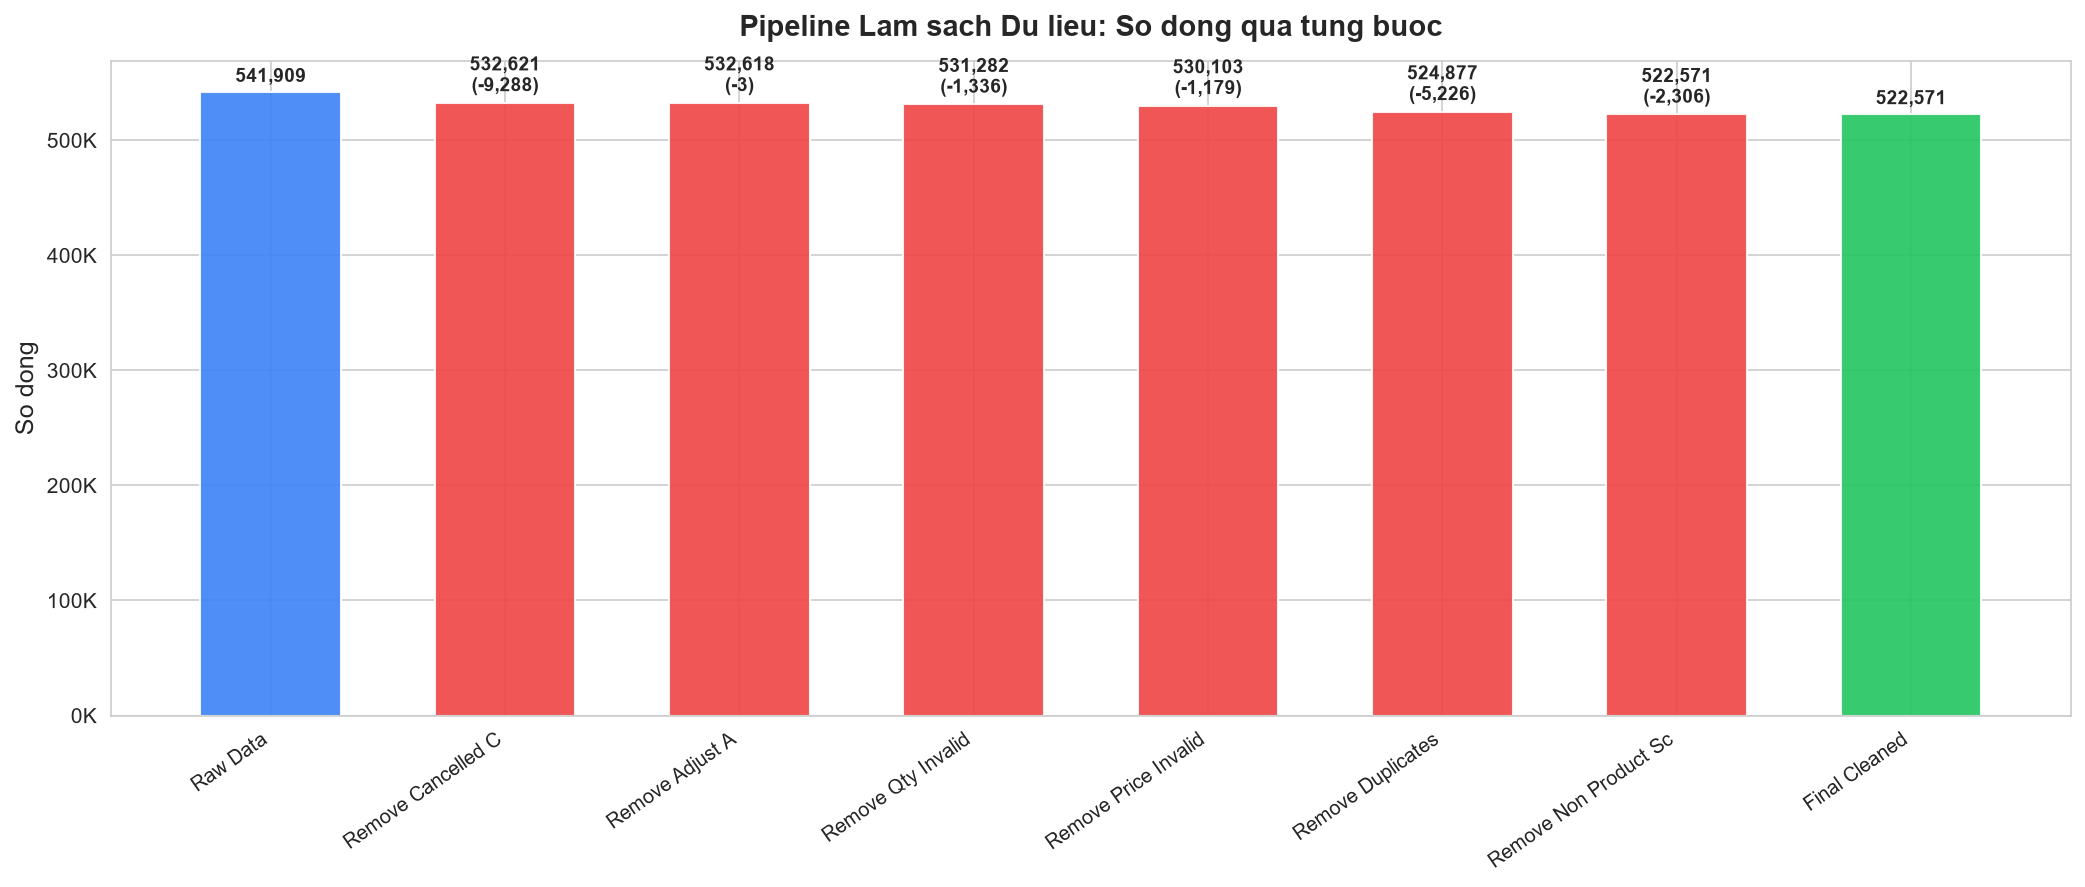

=== 2. Tỷ lệ dòng bị loại theo nguyên nhân ===


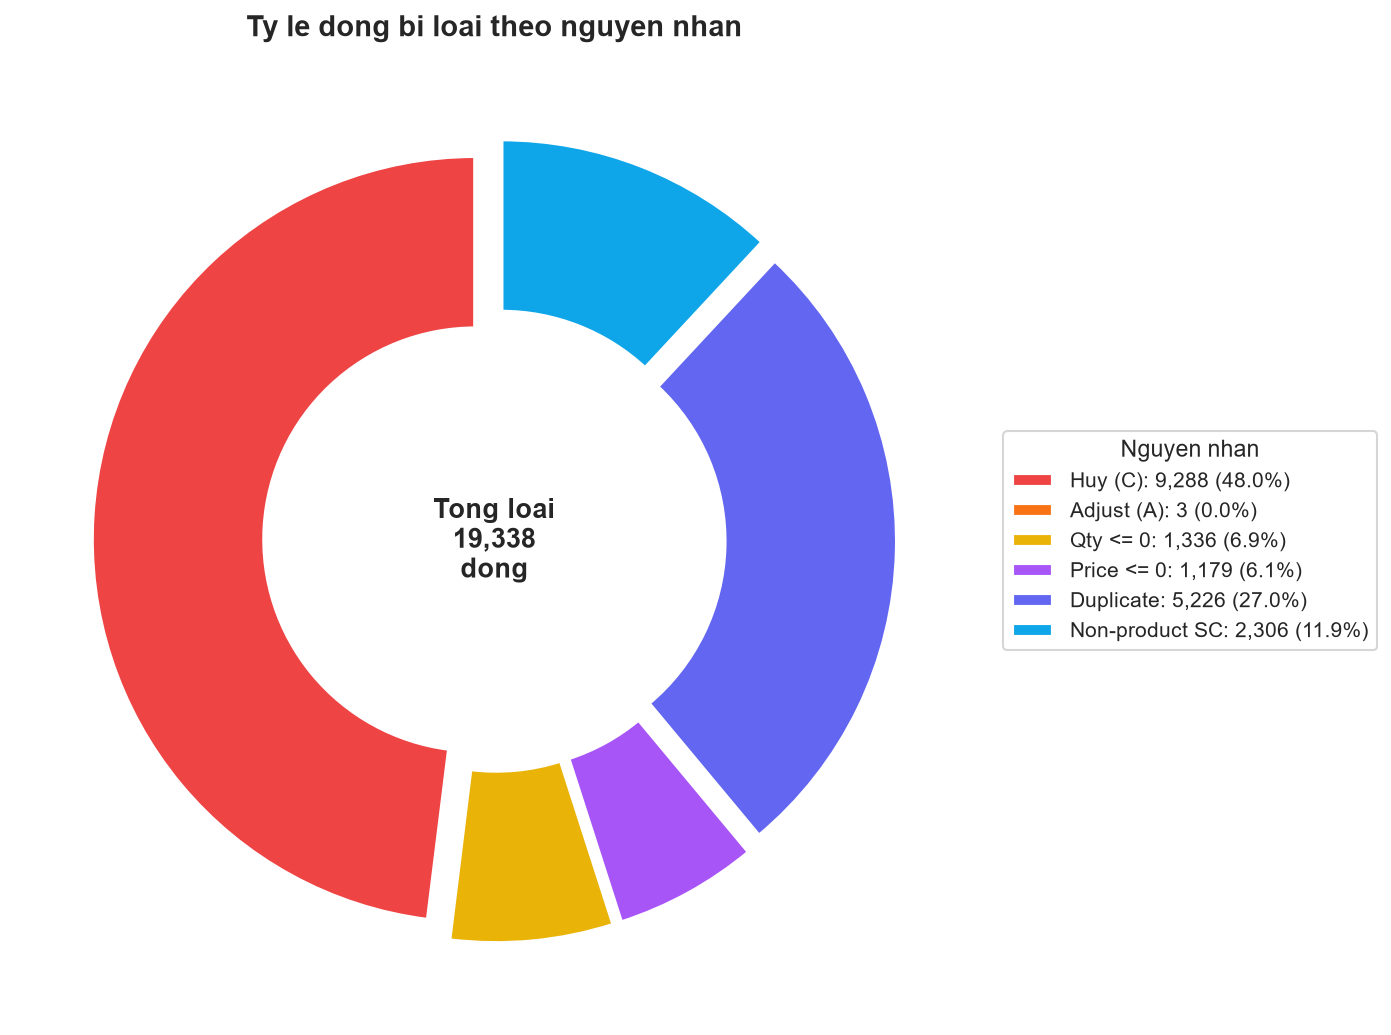

=== 3. Boxplot Quantity Trước & Sau ===


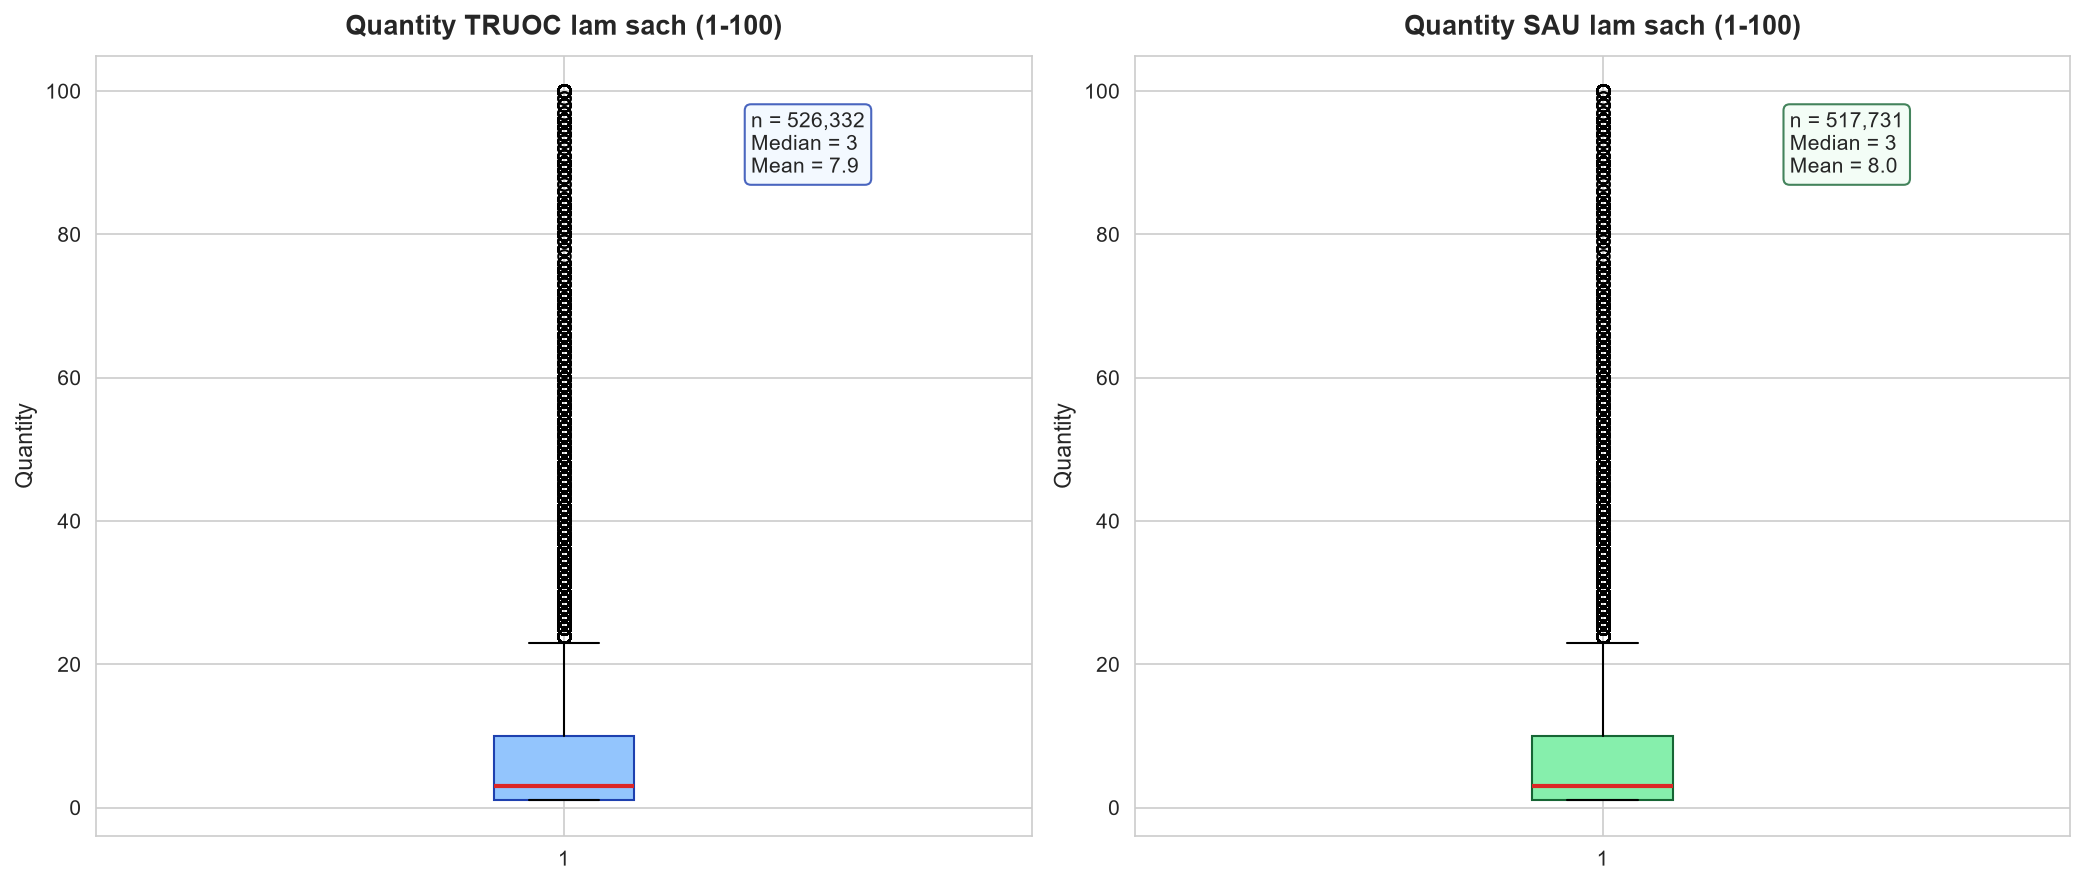

=== 4. Boxplot UnitPrice Trước & Sau ===


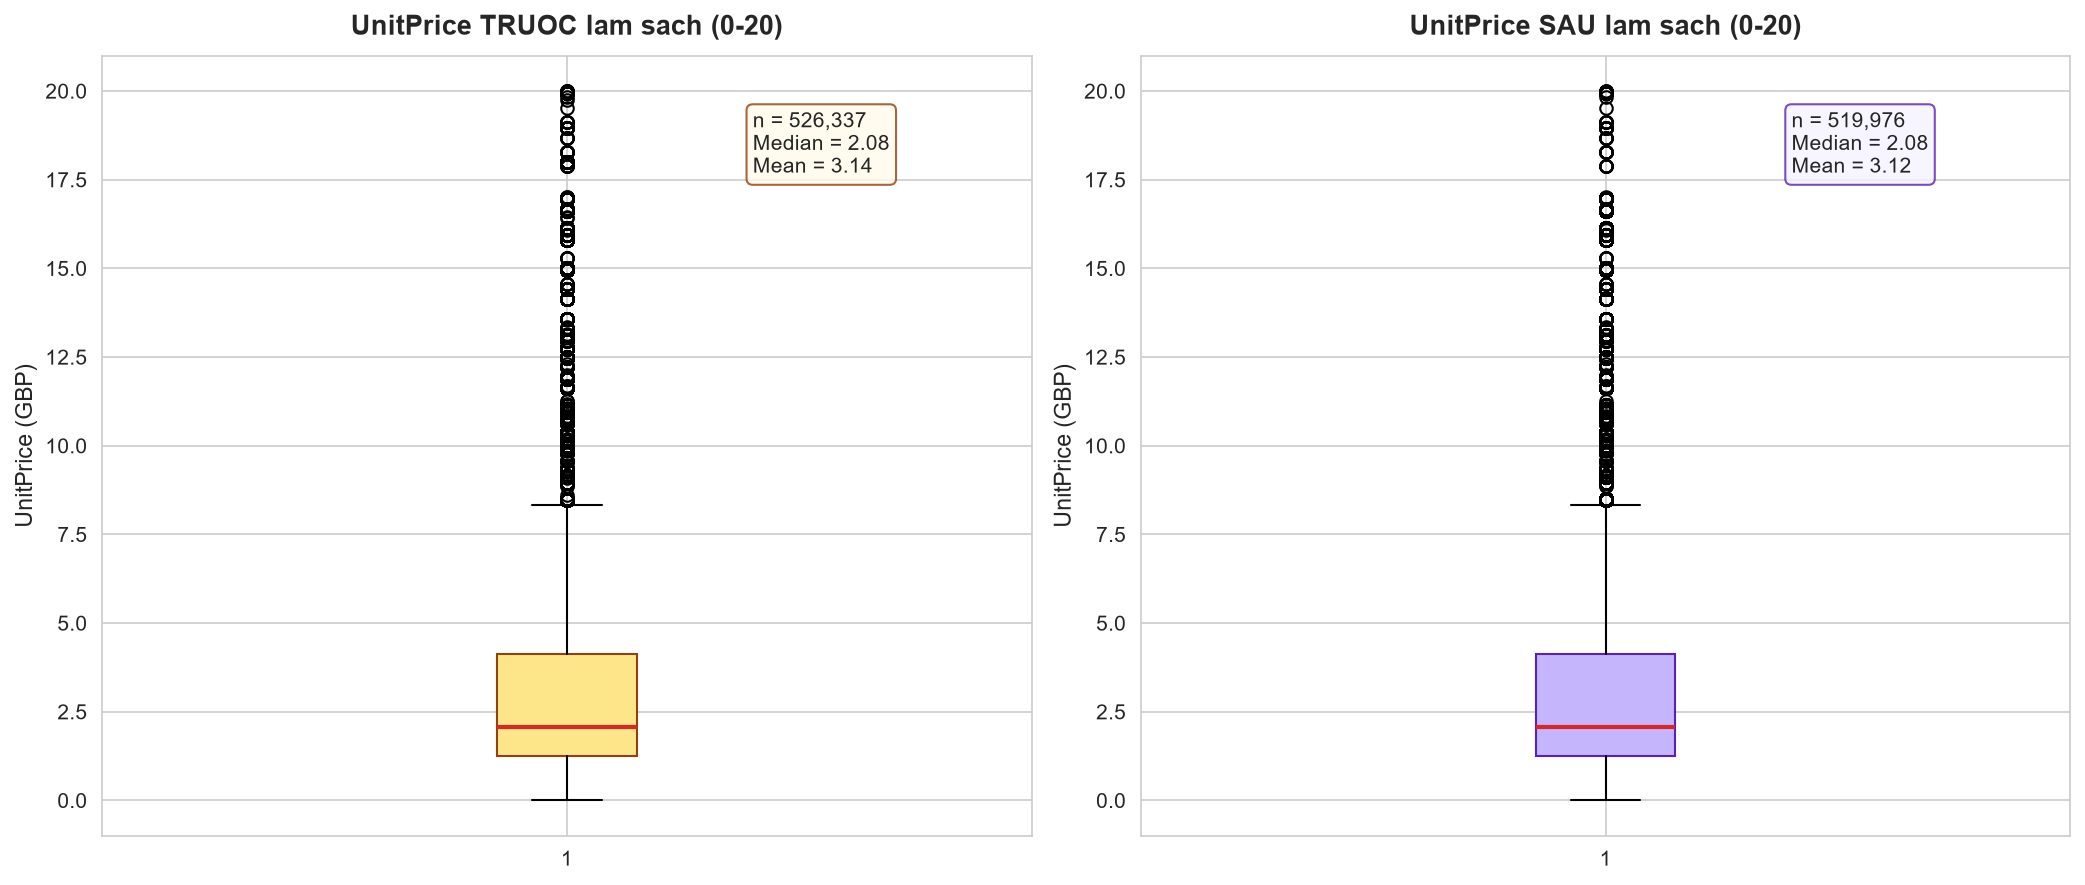

=== 5. Phân phối TotalAmount Trước & Sau (Log10) ===


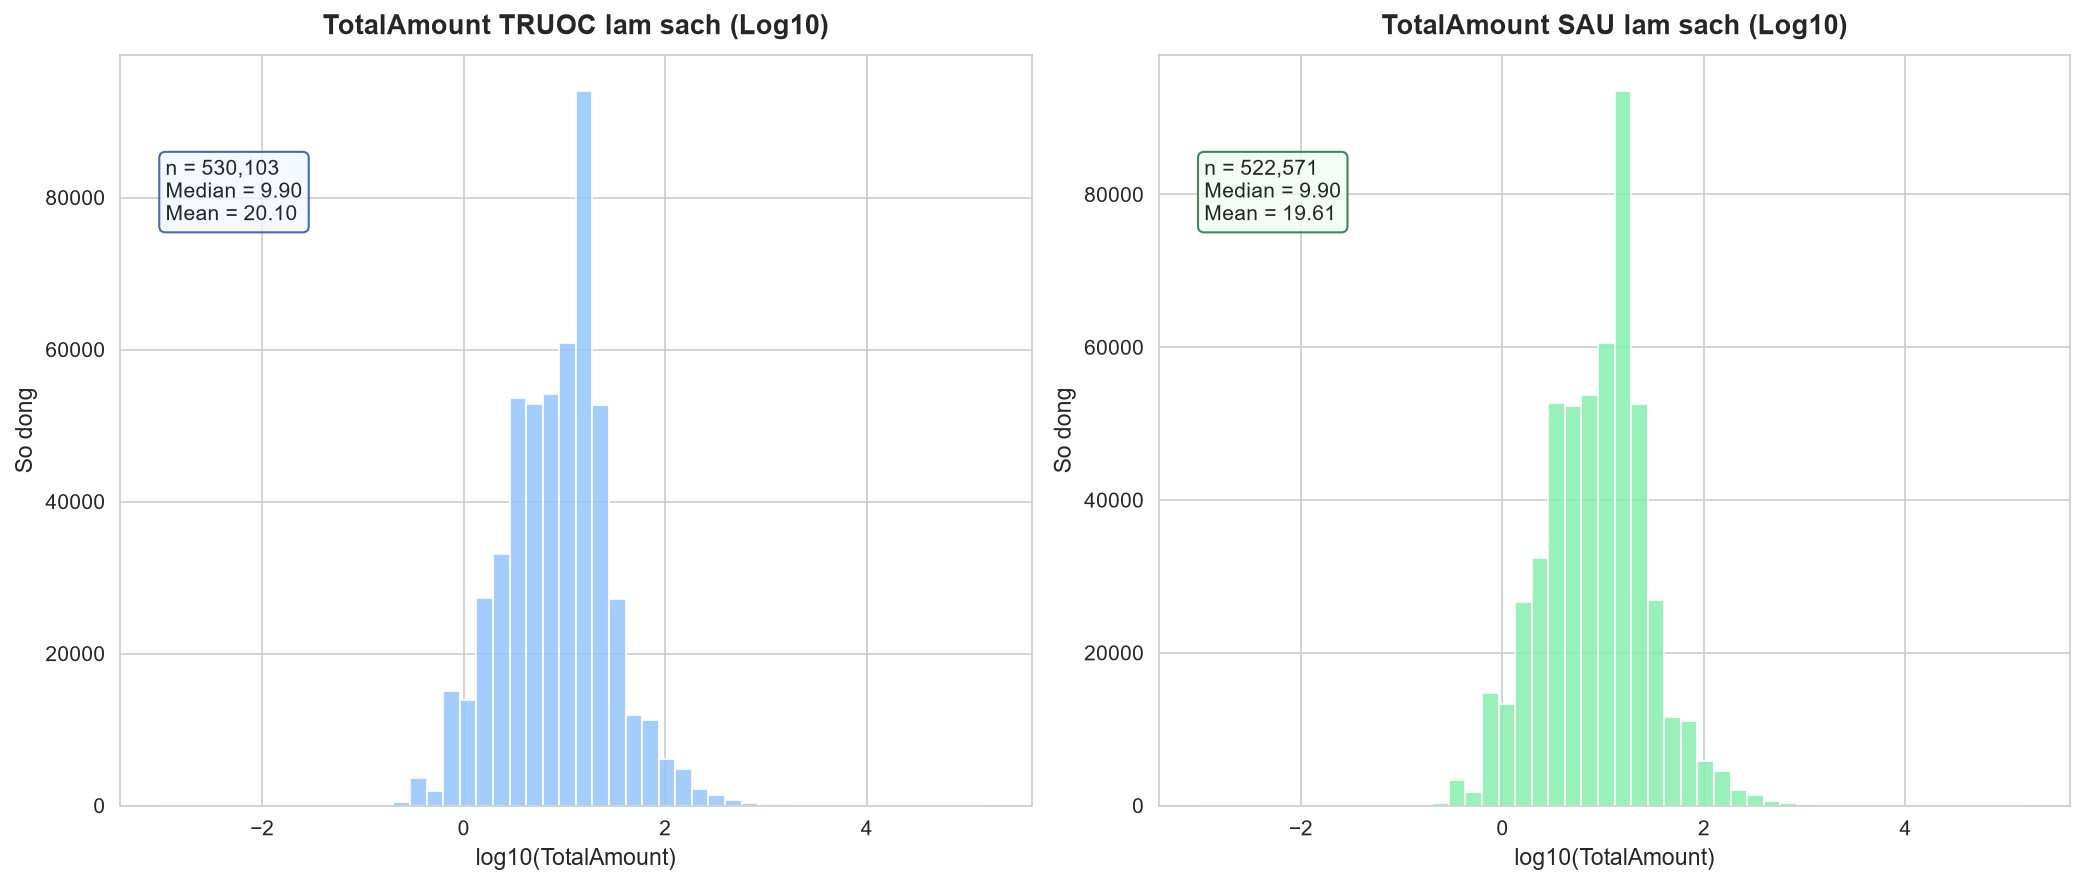

=== 6. Doanh thu theo tháng Trước & Sau ===


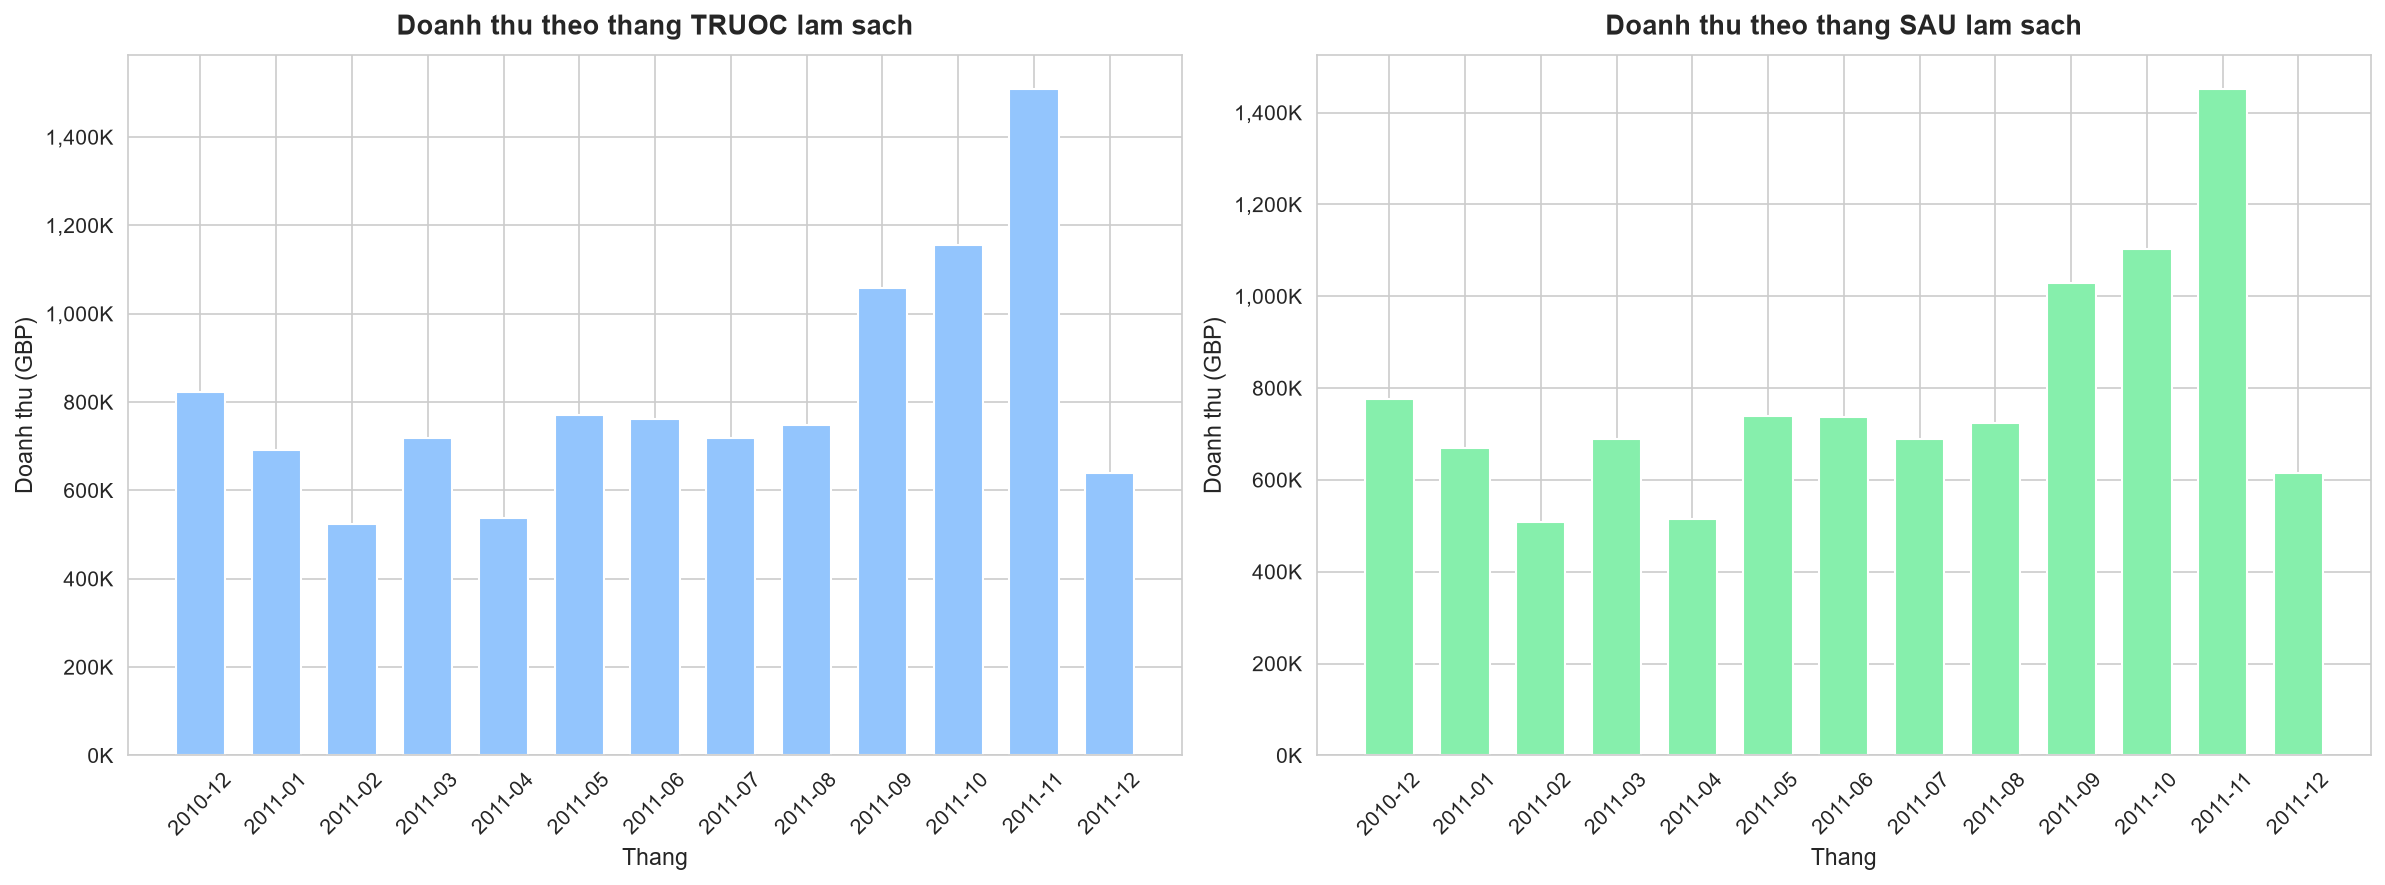

=== 7. Phát hiện Outlier bằng IQR ===


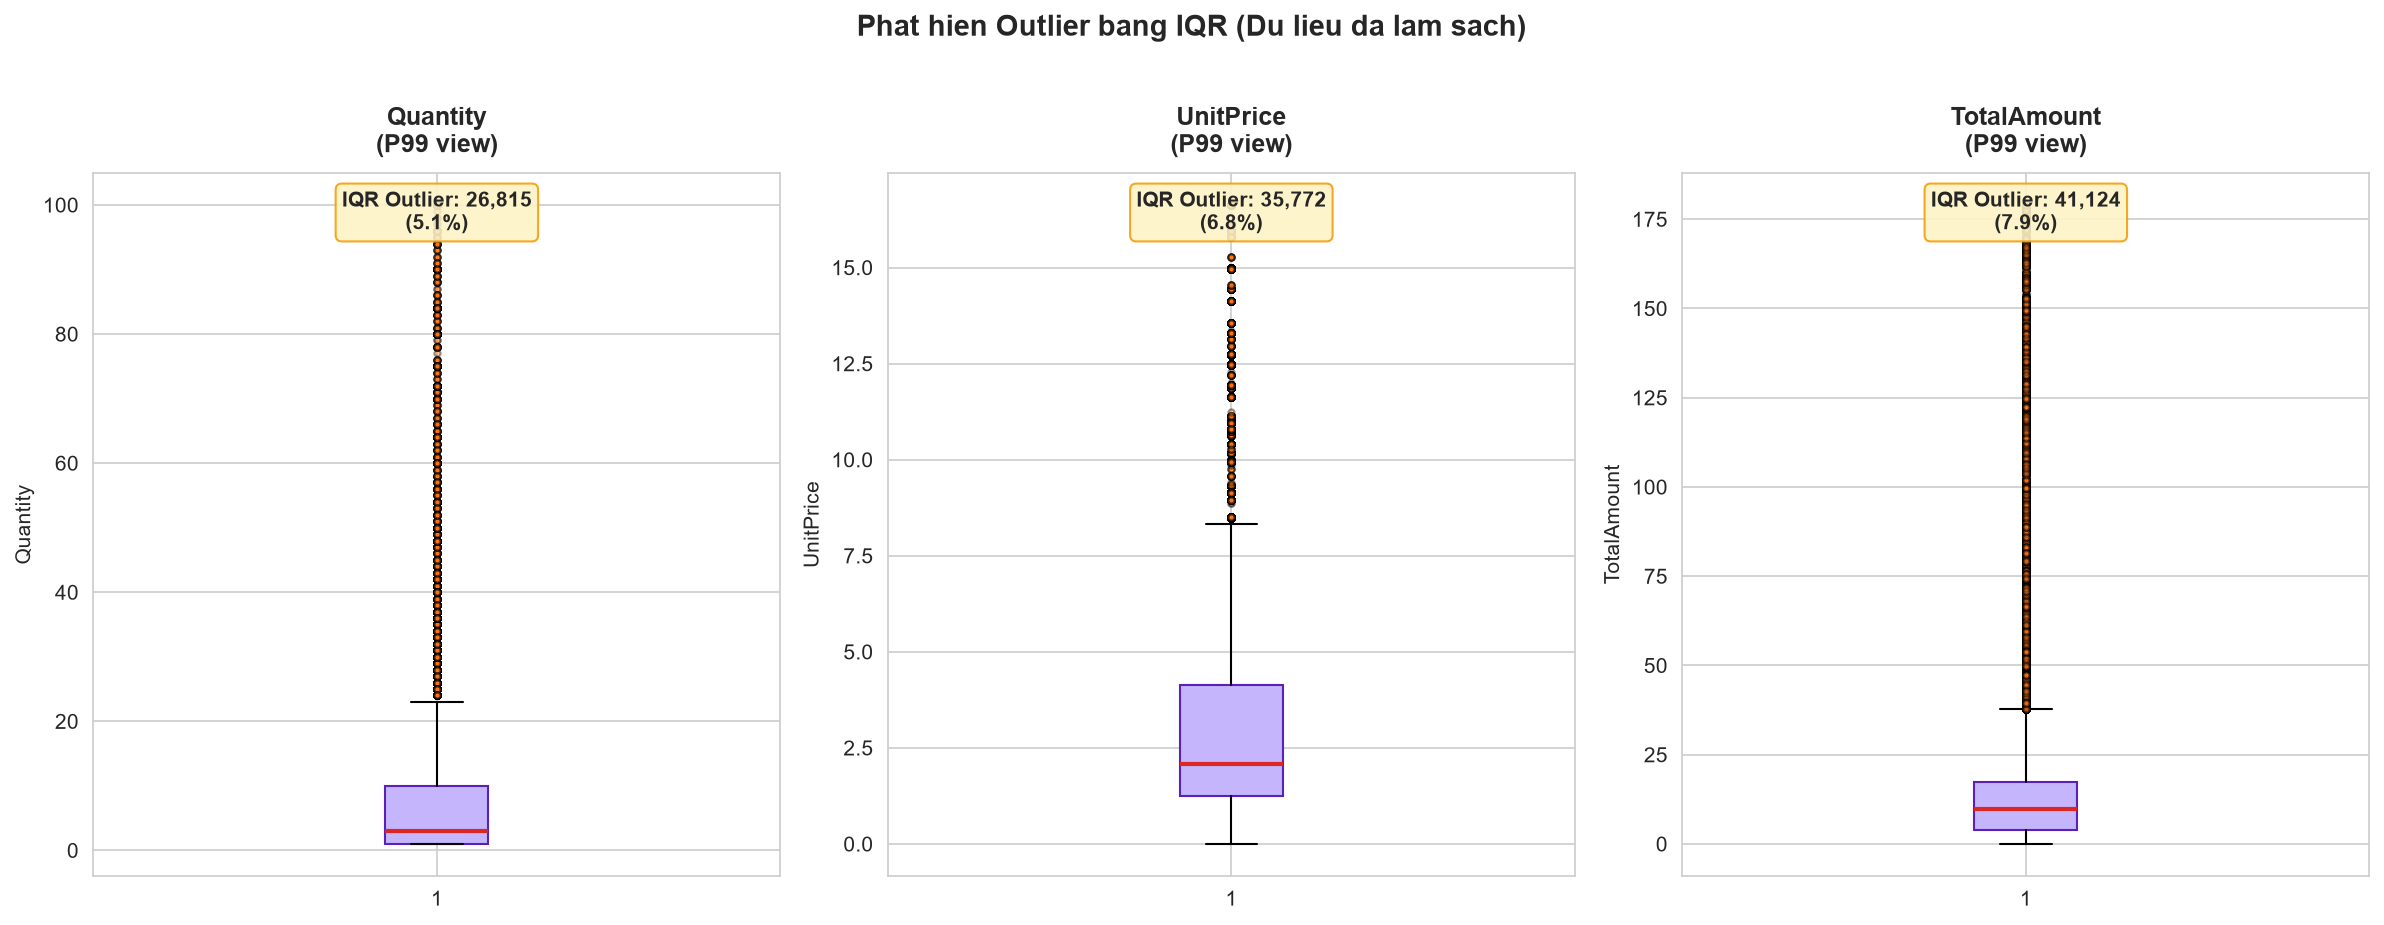

=== 8. Missing Values Trước & Sau ===


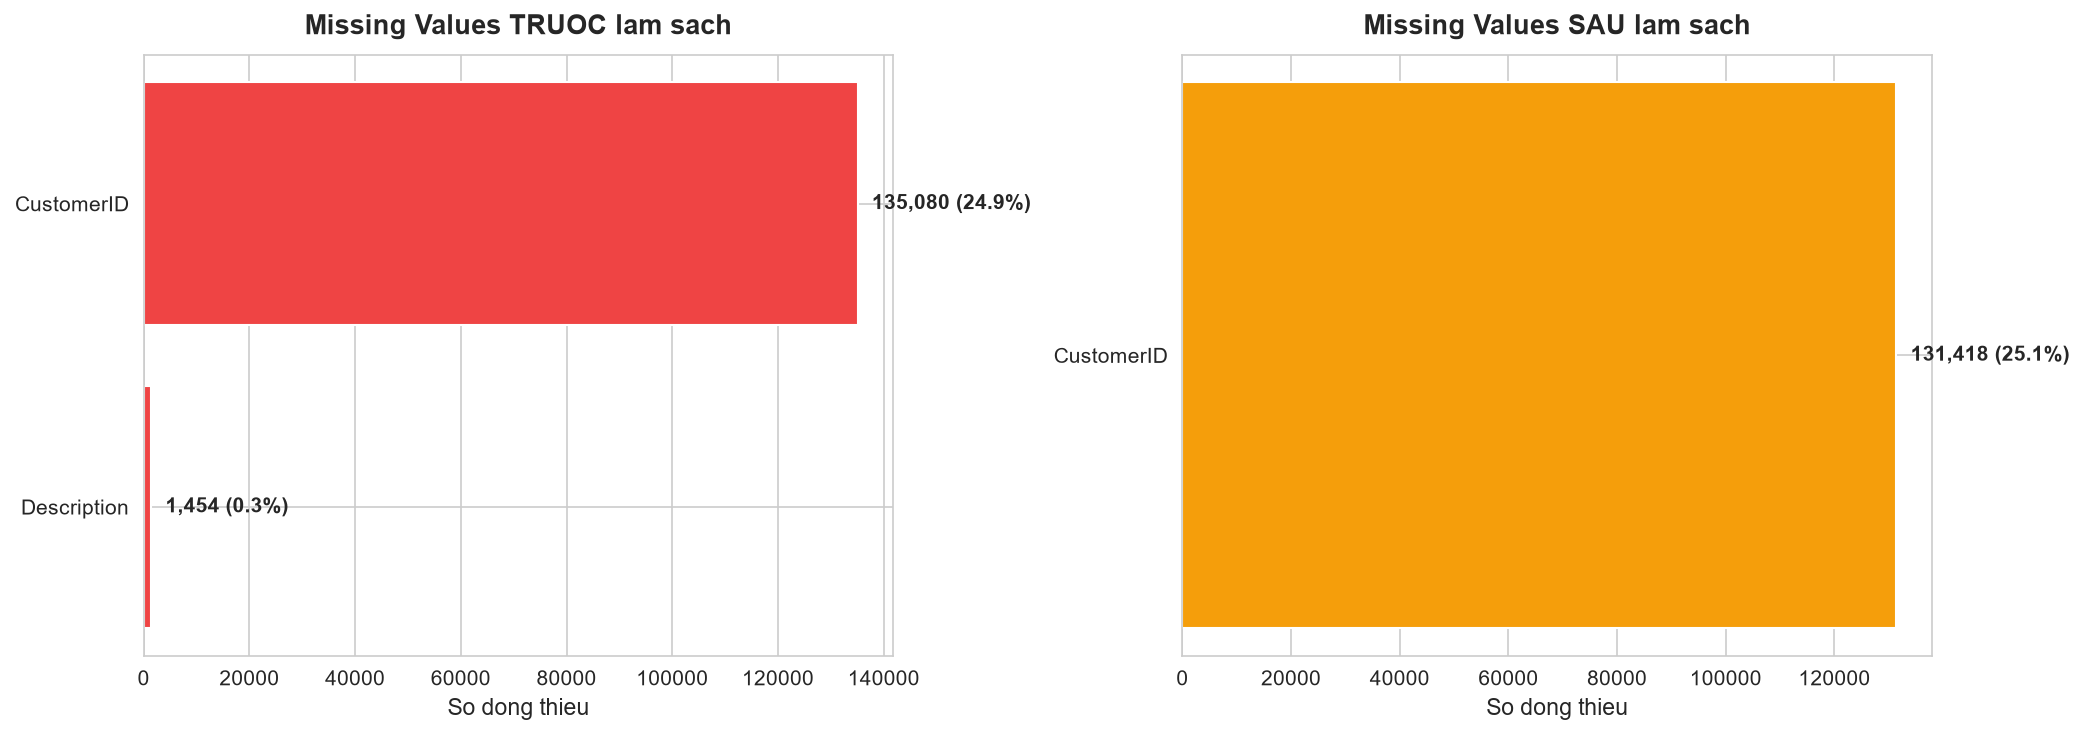

In [14]:
from IPython.display import Image, display

figures = [
    ('1. Pipeline Làm sạch (Cleaning Funnel)', FIGURES_DATA_PREPARATION / 'cleaning_funnel.png'),
    ('2. Tỷ lệ dòng bị loại theo nguyên nhân', FIGURES_DATA_PREPARATION / 'removal_reasons_pie.png'),
    ('3. Boxplot Quantity Trước & Sau', FIGURES_DATA_PREPARATION / 'boxplot_quantity_before_after.png'),
    ('4. Boxplot UnitPrice Trước & Sau', FIGURES_DATA_PREPARATION / 'boxplot_unitprice_before_after.png'),
    ('5. Phân phối TotalAmount Trước & Sau (Log10)', FIGURES_DATA_PREPARATION / 'dist_totalamount_before_after.png'),
    ('6. Doanh thu theo tháng Trước & Sau', FIGURES_DATA_PREPARATION / 'revenue_by_month_before_after.png'),
    ('7. Phát hiện Outlier bằng IQR', FIGURES_DATA_PREPARATION / 'outlier_detection.png'),
    ('8. Missing Values Trước & Sau', FIGURES_DATA_PREPARATION / 'missing_values_heatmap.png'),
]

for title, fpath in figures:
    print(f"=== {title} ===")
    if fpath.exists():
        display(Image(filename=str(fpath)))
    else:
        print(f"File chưa tồn tại: {fpath}")


## 14. Kiểm Tra Tính Toàn Vẹn Của Dữ Liệu Gốc (Integrity Check)

Đảm bảo nguyên tắc cốt lõi của kỹ thuật dữ liệu: **Dữ liệu gốc (`data/raw/Online Retail.csv`) hoàn toàn không bị chỉnh sửa hay ghi đè**.


In [15]:
# Tải lại từ file CSV gốc để kiểm tra tính toàn vẹn
df_check = load_raw_data()
assert df_check.shape[0] == raw_rows, f"LỖI: Dữ liệu gốc bị đổi số dòng ({df_check.shape[0]} != {raw_rows})!"
assert df_check.shape[1] == raw_cols, f"LỖI: Dữ liệu gốc bị đổi số cột ({df_check.shape[1]} != {raw_cols})!"
print(f"XÁC NHẬN: Dữ liệu gốc hoàn toàn nguyên vẹn với {df_check.shape[0]:,} dòng x {df_check.shape[1]} cột.")

# Kiểm tra các file đầu ra đã được tạo đầy đủ
expected_interim = [
    INTERIM_DIR / 'cleaned_transactions.csv',
    INTERIM_DIR / 'customer_transactions.csv',
    INTERIM_DIR / 'product_transactions.csv',
]
print("\nTrạng thái các tập dữ liệu interim:")
for p in expected_interim:
    status = "ĐÃ TỒN TẠI" if p.exists() else "CHƯA TỒN TẠI"
    size_mb = p.stat().st_size / (1024 * 1024) if p.exists() else 0
    print(f"  [{status}] {p.name:30s} ({size_mb:.2f} MB)")


[OK] Da tai du lieu: 541,909 dong x 8 cot
XÁC NHẬN: Dữ liệu gốc hoàn toàn nguyên vẹn với 541,909 dòng x 8 cột.

Trạng thái các tập dữ liệu interim:
  [ĐÃ TỒN TẠI] cleaned_transactions.csv       (72.17 MB)
  [ĐÃ TỒN TẠI] customer_transactions.csv      (54.02 MB)
  [ĐÃ TỒN TẠI] product_transactions.csv       (72.17 MB)


## 15. Tổng Kết Quyết Định Tiền Xử Lý

| Vấn đề dữ liệu | Tình trạng trong dữ liệu gốc | Quyết định tiền xử lý | Lý do nghiệp vụ |
|---|---|---|---|
| **InvoiceNo 'C'** | 9,288 dòng (3,836 hóa đơn) | Tách khỏi tập giao dịch mua | Đơn hủy không phải hành vi mua hàng thực tế; giữ lại riêng nếu phân tích tỷ lệ hủy đơn |
| **InvoiceNo 'A'** | 3 dòng (3 hóa đơn) | Loại bỏ hoàn toàn | Bút toán điều chỉnh nợ xấu kế toán, giá trị cực lớn, không phải bán lẻ |
| **Quantity <= 0** | 1,336 dòng (ngoài C/A) | Loại bỏ | Dòng điều chỉnh kho, hỏng hóc, mất mát |
| **UnitPrice <= 0** | 1,179 dòng | Loại bỏ | Hàng mẫu quà tặng (0.00) hoặc lỗi ghi nhận |
| **Duplicate** | 5,226 dòng | Loại bỏ, chỉ giữ bản ghi đầu | Trùng lặp do lỗi truyền dữ liệu hoặc bấm gửi nhiều lần |
| **Non-product StockCode** | 2,306 dòng (`POST`, `DOT`, `M`,...) | Loại bỏ khỏi dữ liệu sản phẩm | Cước vận chuyển, phí sàn, chiết khấu không phải sản phẩm vật lý |
| **Missing Description** | 1,454 dòng | Điền theo mode `StockCode` | Khôi phục thông tin sản phẩm chuẩn; nếu không có gán 'Unknown Product' |
| **Missing CustomerID** | 131,418 dòng | Giữ trong `cleaned_transactions`, lọc trong `customer_transactions` | Khách vãng lai vẫn đóng góp vào doanh thu và sản phẩm, nhưng không thể dùng để phân cụm hay dự đoán khách hàng |
| **Outlier (Quantity/Price)** | 5% - 8% dòng theo IQR | Giữ lại, gắn cờ cảnh báo | Phản ánh hành vi mua buôn/sỉ B2B thực tế, không xóa bỏ tùy tiện |
